In [1]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter
from scipy.sparse.linalg import gmres

### Data

In [25]:
rho = 0.25
sigma_in = 0.1
sigma_ex = 1

# ref sol: expressions in x,y, t (with E_infty = 1)

ref_sol_in_0 = lambda x,y: 2*sigma_ex/(sigma_ex+sigma_in)*x
ref_sol_ex_0 = lambda x,y: x*( 1+ (sigma_ex-sigma_in)/(sigma_ex+sigma_in)*(rho)**2/(x**2+y**2))

ref_sol_in_infty = lambda x,y: 0.0
ref_sol_ex_infty = lambda x,y: x*( 1 + (rho)**2/(x**2+y**2))


ref_sol_in = lambda x, y, t: np.exp(-t)*(ref_sol_in_0(x,y)-ref_sol_in_infty(x,y)) + ref_sol_in_infty(x,y)
ref_sol_ex = lambda x, y, t: np.exp(-t)*(ref_sol_ex_0(x,y)-ref_sol_ex_infty(x,y)) + ref_sol_ex_infty(x,y)

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, t,\
          rho=rho, ref_sol_in=ref_sol_in, ref_sol_ex=ref_sol_ex: \
          ddr.reference_solution(mesh, dof, rho, ref_sol_in, ref_sol_ex, t) 

eta = 1                     # stability parameter

### Mesh-Of-Interface-adapted breaking (copied)

In [15]:
# attention: it returns a list of intersections (if 2, only one edge cuts the face) 
# also return indexes of cut face edges to define ordering of new elements

# the convention for ordering of nodes in new faces is:
# with M= number of new points added (at least 2):
# face1 =[new_nodes, vertex alone]
# face2 =[new_nodes(reverse), 2 vertices together]
# also returns number of face along intface (so you know the first intface_faces are on intface)

def face_edge_intersections(mesh, intface, ifa, ied):
    no_edges_init = 3  # original no of edges of elements
    intersections = []
    cut_face_edges = []
    no_points_per_face = mesh.faces.shape[1] # space in the face buffer

    ied_ino1 = intface.edges[ied][0]
    ied_ino2 = intface.edges[ied][1]
    ied_ino1_coords = intface.coords[ied_ino1][:]
    ied_ino2_coords = intface.coords[ied_ino2][:]

    for ie in (range(no_edges_init)):
        ifa_ino1 = mesh.faces[ifa,ie]
        ifa_ino2 = mesh.faces[ifa, (ie+1)%no_edges_init]
        ifa_ino1_coords = mesh.coords[ifa_ino1,:]
        ifa_ino2_coords = mesh.coords[ifa_ino2,:]
        
        [cut, intsec_coords] = ddr.calc_intersection_segments\
                                    (ifa_ino1_coords,ifa_ino2_coords,\
                                     ied_ino1_coords, ied_ino2_coords)
        if (cut):
            intersections.append(intsec_coords.astype(float))
            cut_face_edges.append(ie)

    return [intersections, cut_face_edges]


# algorithm to split face: basically distinguish case when only one intf edge cuts and when several 
# intf edges cut
# returns 2 new faces as node lists 

def split_face(mesh, intface, ifa, verbose = False):
    
    Npoints = mesh.coords.shape[0]
    No_intf_edges = len(intface.edges)

    # loop over interface edges
    for ied in range(No_intf_edges):
        
            exception = False
            
            # chek if face and edge intersect 
            [intersections,cut_face_edges] = \
                face_edge_intersections(mesh, intface, ifa, ied)

###############################################################################################################

            # CASE of 2 intersections found? follow old procedure
            if (len(intersections)==2):
                
                # Add points if not already there
                intsec1 = intersections[0]
                intsec2 = intersections[1]
                
                [present, int1] = ddr.check_if_present (mesh, intsec1)
                if(not present):
                    mesh.coords = np.vstack([mesh.coords,np.array([intsec1[0], intsec1[1], 0.0])])
                    mesh.Npoints = mesh.coords.shape[0]
                    int1 = mesh.Npoints-1
                [present, int2] = ddr.check_if_present (mesh, intsec2)
                if(not present):
                    mesh.coords = np.vstack([mesh.coords,np.array([intsec2[0], intsec2[1], 0.0])])
                    mesh.Npoints = mesh.coords.shape[0]
                    int2 = mesh.Npoints-1
                    
                # get index of original vertices (first is on cut edge) 
                v1 = mesh.faces[ifa,cut_face_edges[0]]
                v2 = mesh.faces[ifa,(cut_face_edges[0]+1)%3]
                v3 = mesh.faces[ifa,(cut_face_edges[0]+2)%3]
                
                l1 = -1*np.ones(mesh.no_points_per_face + 3)
                l2 = -1*np.ones(mesh.no_points_per_face + 3)
                l1 = l1.astype(int)
                l2 = l2.astype(int)
                
                # return new faces (according to how intf edge cuts face)
                if (cut_face_edges[1]-cut_face_edges[0] ==1):
                    l1[0:3] = [int2, int1, v2]
                    l2[0:4] = [int1,int2,v3,v1]
                if (cut_face_edges[1]-cut_face_edges[0] ==2):
                    l1[0:3] = [int1, int2, v1]
                    l2[0:4] = [int2,int1,v2,v3]                
                
                intf_faces = 1 # only one interface face
                
                return [l1, l2, intf_faces] 
##############################################################################################################                    

            # CASE of 1 intersection found? look for end of chain 
            # and fill list of new nodes
            elif (len(intersections)==1):
                
                #--->whatch out for exception: first intf edge going out of face
                p1 = mesh.coords[mesh.faces[ifa,0],:]
                p2 = mesh.coords[mesh.faces[ifa,1],:]
                p3 = mesh.coords[mesh.faces[ifa,2],:]
                q  = intface.coords[intface.edges[ied][0]]
                # exception case if edge is getting out
                exception = ddr.check_if_in_triangle(p1, p2, p3, q)       
                                    
                if (not exception):
                    new_nodes = [] # list of new nodes
                
                    # first face cut is the only one cut by the first intf edge
                    cut_face_edges1 = cut_face_edges[0]
                
                    # at beginning of new_nodes add first intersection
                    intsec1 = intersections[0]
                    [present, int1] = ddr.check_if_present (mesh, intsec1)
                    if(not present):
                        mesh.coords = np.vstack([mesh.coords,np.array([intsec1[0], intsec1[1], 0.0])])
                        mesh.Npoints = mesh.coords.shape[0]
                        int1 = mesh.Npoints-1
                    new_nodes.append(int1)
                
                    # loop on interface edges until you find 
                    # the second intersection 
                    done = False
                    current_ied = (ied + 1)%No_intf_edges
                
                    while (not done):
                    
                        # add first node of each to point list (if not already present) and to new_nodes
                        idx_point_to_add = intface.edges[current_ied][0]
                        point_to_add = intface.coords[idx_point_to_add]
                        [present, idx] = ddr.check_if_present (mesh, point_to_add) # idx in coords
                                                                     # whereas idx_point_to_add is in 
                                                                     # intf_coords
                        if(not present):
                            mesh.coords = np.vstack \
                                ([mesh.coords,np.array([point_to_add[0], point_to_add[1], 0.0])])
                            mesh.Npoints = mesh.coords.shape[0]
                            idx = mesh.Npoints-1
                        new_nodes.append(idx)
                    
                        # check if intersection
                        # if intersection set done=true, add last point to new_nodes and register 
                        [intersections,cut_face_edges] = \
                             face_edge_intersections(mesh, intface, ifa, current_ied)
                        if (len(intersections)>0):
                            cut_face_edges2 = cut_face_edges[0]
                            intsec2 = intersections[0]
                            [present, int2] = ddr.check_if_present (mesh, intsec2)
                            if(not present):
                                mesh.coords = np.vstack([mesh.coords,np.array([intsec2[0], intsec2[1], 0.0])])
                                mesh.Npoints = mesh.coords.shape[0]
                                int2 = mesh.Npoints-1
                            new_nodes.append(int2)
                            done = True    
                    
                        # advance loop
                        current_ied = (current_ied + 1)%No_intf_edges #---> loop can begin again
                    
                
                    # get index of original vertices in order of cut (first is on cut edge) 
                    v1 = mesh.faces[ifa,cut_face_edges1]
                    v2 = mesh.faces[ifa,(cut_face_edges1+1)%3]
                    v3 = mesh.faces[ifa,(cut_face_edges1+2)%3]
                
                    l1 = -1*np.ones(mesh.no_points_per_face + 3)
                    l2 = -1*np.ones(mesh.no_points_per_face + 3)
                    l1 = l1.astype(int)
                    l2 = l2.astype(int)
                
                    no_new_nodes = len(new_nodes)
                    
                    if (verbose):
                        print (new_nodes)
                
                    # determine if case 1 or case 2
                    
                    case = 3*(cut_face_edges2<cut_face_edges1) + (cut_face_edges2 - cut_face_edges1) 
                    
                    if (verbose):
                        print ("case", case)
                    
                    # return new faces (according to how intf edge cuts face)
                    if (case == 1):
                        
                    
                        l1[0:no_new_nodes] = new_nodes[::-1]
                        l1[no_new_nodes] = v2
                    
                        l2[0:no_new_nodes] = new_nodes
                        l2[no_new_nodes:no_new_nodes+2] = [v3,v1]
                    
                    if (case == 2):
                    
                        l1[0:no_new_nodes] = new_nodes
                        l1[no_new_nodes] = v1
                    
                        l2[0:no_new_nodes] = new_nodes[::-1]
                        l2[no_new_nodes:no_new_nodes+2] = [v2,v3]  
     
                    if (verbose):
                        print ("cut edges: ", cut_face_edges1, cut_face_edges2)
        
                    intf_faces = len(new_nodes)-1 # N-1 new faces along interface

                    return [l1,l2, intf_faces]
                
                #-------->Exception
                # just do nothing: the loop will find the next intersection 
                else:
                    if (verbose):
                        print ("Exception")
                
            
def break_mesh(mesh, intface, verbose = False):
    
    for ifa in range(mesh.Nfaces_init):
        
        #Check if face is cut by circle
        if (ddr.is_cut(mesh, ifa, rho)):
            
            if (verbose):
                print ("Face: ", ifa)
            # Mask the Face
            mesh.cut_faces[ifa] = 1
            # Create new nodes and faces
            [f1, f2, intf_faces] = split_face(mesh, intface, ifa, verbose)
            if (verbose):
                print (f1)
                print (f2)
            
            # Update list of faces, mask of cut faces, and counter of intf_faces
            mesh.faces = np.vstack([mesh.faces,np.array(f1)])
            mesh.faces = np.vstack([mesh.faces, np.array(f2)])
            mesh.cut_faces = np.append(mesh.cut_faces,2)
            mesh.cut_faces = np.append(mesh.cut_faces,2)
            mesh.no_intf_edges = np.append(mesh.no_intf_edges,intf_faces)
            mesh.no_intf_edges = np.append(mesh.no_intf_edges,intf_faces)
            
            mesh.Nfaces = mesh.faces.shape[0]
            
            # Update size
            mesh.Npoints = mesh.coords.shape[0]
            
            # Define number of dofs
            mesh.Ndof = mesh.Npoints_init + 2*(mesh.Npoints-mesh.Npoints_init)

            # Update side_mask and gamma_couples
            mesh.side_mask=np.append(mesh.side_mask,-1)
            mesh.side_mask=np.append(mesh.side_mask,-1)
            if (np.linalg.norm(ddr.barycenter(mesh, mesh.Nfaces-2))<rho):
                mesh.side_mask[mesh.Nfaces-2] = 0
                mesh.gamma_couples.append([mesh.Nfaces-2, mesh.Nfaces-1])
            else:
                mesh.side_mask[mesh.Nfaces-2] = 1
                mesh.gamma_couples.append([mesh.Nfaces-1, mesh.Nfaces-2])
            if (np.linalg.norm(ddr.barycenter(mesh, mesh.Nfaces-1))<rho):
                mesh.side_mask[mesh.Nfaces-1] = 0
            else:
                mesh.side_mask[mesh.Nfaces-1] = 1      
            
        elif (np.linalg.norm(ddr.barycenter(mesh, ifa))<rho):
            mesh.side_mask[ifa] = 0
        else:
            mesh.side_mask[ifa] = 1

### Load and Break Mesh

### M_Gamma and N_Gamma (Copied)

In [6]:
def assemble_M_gamma(mesh, sigma_in, sigma_ex):

    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    
    
    for ico in range(len(mesh.gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs interested by the edge
        
        ifa_in = mesh.gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = mesh.gamma_couples[ico][1]
        
        no_intf_nodes  = mesh.no_intf_edges[ifa_in] + 1 
        
        tot_dofs = int(2*no_intf_nodes + 3) # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        
        if (node_per_face_in+node_per_face_ex != tot_dofs):
            print ("Error with Dof counting")
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
# assemble matrix            
################################################################################################################
            
        # loop over dof1 
        for idof1 in range(tot_dofs):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face
            
            GR1 = ddr.GR( mesh, ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)

            
            # loop over dof2 
            for idof2 in range(tot_dofs):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1] #idx of face

                
                # loop over interface edges of the couple 
                for ied in range(mesh.no_intf_edges[ifa_in]):
                    
                    ino1_edge = mesh.faces[ifa_in,ied] # worked out from face1
                    ino2_edge = mesh.faces[ifa_in, ied+1]
                    ino_dof2  = mesh.faces[ifa2, dof2_loc]
                    
                    # non null contribution if edge in support of phi_j
                    if (ino_dof2==ino1_edge or ino_dof2==ino2_edge):
            
                        # find normal
                        tangent = mesh.coords[mesh.faces[ifa1,(ied+1)],0:2] \
                                 -mesh.coords[mesh.faces[ifa1, ied   ],0:2] # should be safe not to take %
                        normal  = sign1*np.array([[0,1],[-1,0]])@tangent
                        # G(phi_i) times normal
                        mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc], normal)
                        
                        # sign of jump 
                        sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)                       
                    
                        # add contribution
                        M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*sign2*0.5
            
    return M_gamma         

M_gamma = assemble_M_gamma(mesh, sigma_in ,sigma_ex)

#####################################################################################
#####################################################################################
#####################################################################################


def assemble_N_gamma(mesh):
    
    N_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    
    for ico in range(len(mesh.gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs touched by the edge
        
        ifa_in = mesh.gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = mesh.gamma_couples[ico][1]
        
        no_intf_nodes  = mesh.no_intf_edges[ifa_in] + 1 
        
        tot_dofs = 2*no_intf_nodes + 3 # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        
        if (node_per_face_in + node_per_face_ex != tot_dofs):
            print ("Error")
            
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        
        #print("*******")
        #print(edge_dofs)
            
# assemble matrix            
################################################################################################################
            
        # loop over dof1
        for idof1 in range(tot_dofs):

            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face           
            
            # loop over dof2
            for idof2 in range(tot_dofs):

                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1] #idx of face
                
                
                # loop over interface edges of the couple
                for ied in range(mesh.no_intf_edges[ifa1]):
                    
                    ino1_edge = mesh.faces[ifa1,ied] # worked out from face1
                    ino2_edge = mesh.faces[ifa1, ied+1]
                    ino_dof1  = mesh.faces[ifa1, dof1_loc]
                    ino_dof2  = mesh.faces[ifa2, dof2_loc]
                    
                    v1A = ddr.kron(ino_dof1, ino1_edge)
                    v1B = ddr.kron(ino_dof1, ino2_edge)
                    v2A = ddr.kron(ino_dof2, ino1_edge)
                    v2B = ddr.kron(ino_dof2, ino2_edge)
                    
                    sign1 = int(ifa1==ifa_ex)-int(ifa1==ifa_in)
                    sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                    
                    tangent = mesh.coords[mesh.faces[ifa1,(ied+1)],0:2] \
                             -mesh.coords[mesh.faces[ifa1, ied   ],0:2]
                    mod_E = np.linalg.norm(tangent)
                    
                    # add contribution
                    N_gamma[dof1,dof2] = N_gamma[dof1,dof2] \
                              +  sign1*sign2*mod_E*ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B) 
            
    return N_gamma         

N_gamma = assemble_N_gamma(mesh)

### Boundary Treatment

In [19]:
# function to create connectivity bnd_edge2[node1,node2]
def create_bnd_connectivity(mesh):
    bnd_edges = []
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            for ie in range(node_per_face):
                ino1 = mesh.faces[ifa,ie] # should be counter clockwise
                ino2 = mesh.faces[ifa,(ie+1)%node_per_face]
                if (mesh.bnd_mask[ino1]>0 and mesh.bnd_mask[ino2]>0):
                    edge = np.array([ifa,ie,(ie+1)%node_per_face]) # record face and 2 local dofs
                    bnd_edges.append(edge)
    return bnd_edges

def assemble_FLUX_bnd(mesh, bnd_edges, sigma_min, sigma_plus, visualize):
    if (visualize): 
        fig, ax = plt.subplots(figsize=(20,20))
    to_check = 5
    # visualize underlying mesh
    #################################################################
    if (visualize):
        for ifa in range(mesh.Nfaces):
            if (mesh.cut_faces[ifa]!=1):
                nvert = np.count_nonzero(mesh.faces[ifa,:] != -1)
                for ino in range(nvert):
                    p1 = mesh.coords[mesh.faces[ifa,ino],:]
                    glob_ino = mesh.faces[ifa,(ino+1)%nvert]
                    p2 = mesh.coords[glob_ino,:]
                    dx = p2-p1
                    xx = [p1[0],p2[0]]
                    yy = [p1[1],p2[1]]
                    ax.plot(xx,yy,'k', linewidth=0.1)
    ##################################################################
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa, locdof1] # index of node
        ino2 = mesh.faces[ifa, locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        # fluxes of test functions
        G = ddr.GR(mesh, ifa)
        tangent = p2 - p1
        normal = np.array([[0,1],[-1,0]])@tangent[0:2]
        # sigma
        sigma = sigma_plus # -----------------> internal interface
        ###############################################################
        # visualize normal (suppressed section)
        if (visualize):
            midpoint = 0.5*(p1+p2)
            ax.plot((p1[0], p2[0]), (p1[1], p2[1]))
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
        ###############################################################
        node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
        # loop over all dofs of elements
        for locdof in range(node_per_face):
            idof = ddr.glob_idx(mesh, ifa, locdof) # global dof
            flux = sigma*np.dot(G[:,locdof], normal)
            if (visualize):
                normal = normal/np.linalg.norm(normal)*flux/10
                ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1], color = "red")
            DIR[idof1,idof] = DIR[idof1,idof] + flux*0.5
            DIR[idof2,idof] = DIR[idof2,idof] + flux*0.5
    return DIR

# function to assemble DIR matrix
def assemble_DIR_matrix(mesh, bnd_edges):
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa,locdof1] # index of node
        ino2 = mesh.faces[ifa,locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        DIR[idof1,idof1] = DIR[idof1,idof1] + ddr.calc_r2_prod_integ(v1A,v1B,v1A,v1B) # notice, it's symmetric
        DIR[idof1,idof2] = DIR[idof1,idof2] + ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
        DIR[idof2,idof1] = DIR[idof2,idof1] + ddr.calc_r2_prod_integ(v2A,v2B,v1A,v1B)
        DIR[idof2,idof2] = DIR[idof2,idof2] + ddr.calc_r2_prod_integ(v2A,v2B,v2A,v2B)
    return DIR

# function to assemble b_g vector
def assemble_b_dir(mesh, bnd_edges, ref_sol, t):
    b_dir = np.zeros(mesh.Ndof)
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # local dof
        locdof2 = bnd_edges[ie][2]
        ino1  = mesh.faces[ifa,locdof1] # index of node
        ino2  = mesh.faces[ifa,locdof2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2]
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        gA = ref_sol(mesh, idof1, t)
        gB = ref_sol(mesh, idof2, t)
        b_dir[idof1] = b_dir[idof1] + ddr.calc_r2_prod_integ(v1A,v1B,gA,gB) # notice, it's symmetric
        b_dir[idof2] = b_dir[idof2] + ddr.calc_r2_prod_integ(v2A,v2B,gA,gB)
    return b_dir

In [20]:
def impose_bc(mesh,A,b,ref_sol, t):
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            b[dof] = ref_sol(mesh,dof, t)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]

# b_J with varying Jump

### Node-valued Jump

In [8]:
# Jump Value (defined on every node for praticity)
no_new_points = mesh.Npoints - mesh.Npoints_init
jump = np.zeros(no_new_points)

### Jump Evolution

In [88]:
def assemble_gamma_mass(mesh):
    
    no_new_points = mesh.Npoints - mesh.Npoints_init
    gamma_mass = np.zeros((no_new_points, no_new_points))
    
    for ico in range(len(mesh.gamma_couples)):

        ifa_in = mesh.gamma_couples[ico][0]   
        ifa_ex = mesh.gamma_couples[ico][1]
        
        # loop over interface edges of the couple
        for ied in range(mesh.no_intf_edges[ifa_in]):
                
            ino1_abs = mesh.faces[ifa_in,ied]    # index of node in list of all nodes
            ino2_abs = mesh.faces[ifa_in, ied+1]
            
            ino1 = ino1_abs - mesh.Npoints_init # index of node in list of intface nodes
            ino2 = ino2_abs - mesh.Npoints_init
            
            tangent = mesh.coords[mesh.faces[ifa_in,(ied+1)],0:2] \
                     -mesh.coords[mesh.faces[ifa_in, ied],0:2]
            mod_E = np.linalg.norm(tangent)  
            
            # base fun associted to ino1 takes values [1, 0]
            # base fun associted to ino2 takes values [0, 1]            
            gamma_mass[ino1,ino1] = gamma_mass[ino1,ino1] + ddr.calc_r2_prod_integ(1,0,1,0)*mod_E
            gamma_mass[ino2,ino2] = gamma_mass[ino2,ino2] + ddr.calc_r2_prod_integ(0,1,0,1)*mod_E
            gamma_mass[ino1,ino2] = gamma_mass[ino1,ino2] + ddr.calc_r2_prod_integ(1,0,0,1)*mod_E
            gamma_mass[ino2,ino1] = gamma_mass[ino2,ino1] + ddr.calc_r2_prod_integ(0,1,1,0)*mod_E

    return gamma_mass


def assemble_jump_rhs (mesh, u, sigma_in, sigma_ex, verbose = False):
    
    no_new_points = mesh.Npoints - mesh.Npoints_init
    jump_rhs = np.zeros(no_new_points)
    
    for ico in range(len(mesh.gamma_couples)):

        ifa_in = mesh.gamma_couples[ico][0]   
        ifa_ex = mesh.gamma_couples[ico][1]
        
        GR_in = ddr.GR(mesh, ifa_in)
        GR_ex = ddr.GR(mesh, ifa_ex)
        
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        
        u_in = u[mesh.faces[ifa_in,0:node_per_face_in]]
        grad_in = np.dot(GR_in, u_in)
        
        u_ex = u[mesh.faces[ifa_ex,0:node_per_face_ex]]
        grad_ex = np.dot(GR_ex, u_ex)
        
       
        
        # loop over interface edges of the couple
        for ied in range(mesh.no_intf_edges[ifa_in]):
                
            ino1_abs = mesh.faces[ifa_in, ied]    # index of node in list of all nodes
            ino2_abs = mesh.faces[ifa_in, ied+1]
            
            ino1 = ino1_abs - mesh.Npoints_init # index of node in list of intface nodes
            ino2 = ino2_abs - mesh.Npoints_init

            tangent = mesh.coords[mesh.faces[ifa_in,(ied+1)],0:2] \
                     -mesh.coords[mesh.faces[ifa_in, ied],0:2]
            mod_E = np.linalg.norm(tangent)
            normal  = np.array([[0,1],[-1,0]])@tangent
            
            # 
            sigma_grad_normal_in = sigma_in*np.dot(grad_in, normal)
            sigma_grad_normal_ex = sigma_ex*np.dot(grad_ex, normal)
            
            if (verbose):
                print (np.abs(sigma_grad_normal_in - sigma_grad_normal_ex))
            
            # USE ONLY ONE SIDE 
            jump_rhs[ino1] = jump_rhs[ino1] + sigma_grad_normal_in*0.5
            jump_rhs[ino2] = jump_rhs[ino2] + sigma_grad_normal_in*0.5
    
    return jump_rhs
            
            
def advance_jump (mesh, u, sigma_in, sigma_ex, gamma_mass, jump, C_m, dt, verbose = False):
    
    jump_rhs = assemble_jump_rhs (mesh, u, sigma_in, sigma_ex, verbose)
    
    b = jump_rhs*dt/C_m
    
    updated_jump = np.linalg.solve (gamma_mass, b + np.dot(gamma_mass, jump))
    
    return updated_jump
    

In [11]:
def assemble_b_J(mesh, jump_value):
    
    B_J_gamma = np.zeros(mesh.Ndof)
    
    for ico in range(len(mesh.gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs touched by the edge
        
        ifa_in = mesh.gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = mesh.gamma_couples[ico][1]
        
        no_intf_nodes  = mesh.no_intf_edges[ifa_in] + 1 
        
        tot_dofs = 2*no_intf_nodes + 3 # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
# assemble matrix            
################################################################################################################
            
        # loop over dof 
        for idof in range(tot_dofs):
            dof = edge_dofs[idof,0] #global idx
            if (idof<node_per_face_in): #local idx
                dof_loc = idof
            else:
                dof_loc = idof-node_per_face_in
            ifa = edge_dofs[idof,1] #idx of face
            
            sign = int(ifa==ifa_ex)-int(ifa==ifa_in)
        
            # loop over interface edges of the couple
            for ied in range(mesh.no_intf_edges[ifa]):
                
                ino1_edge = mesh.faces[ifa,ied]    # worked out from face1
                ino2_edge = mesh.faces[ifa, ied+1]
                
                ino1_edge_rel = ino1_edge-mesh.Npoints_init    # idx in a list of only new nodes
                ino2_edge_rel = ino2_edge-mesh.Npoints_init
                
                ino_dof   = mesh.faces[ifa, dof_loc]
                
                v1A = ddr.kron(ino_dof, ino1_edge)
                v1B = ddr.kron(ino_dof, ino2_edge)
                
                v2A = jump_value [ino1_edge_rel]
                v2B = jump_value [ino2_edge_rel]
                    
                tangent = mesh.coords[mesh.faces[ifa,(ied+1)],0:2] \
                         -mesh.coords[mesh.faces[ifa, ied],0:2]
                mod_E = np.linalg.norm(tangent)
                    
                # add contribution
                B_J_gamma[dof] = B_J_gamma[dof] \
                                     + sign*mod_E*ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B) 
            
    return B_J_gamma         

b_J_gamma = assemble_b_J(mesh, jump)

## Time Loop

In [84]:
# Load Square Interface
mesh = ddr.load_square_mesh("square_L1_N5.msh", no_points_per_face=10)

# Load Disk Interface
N = 50
rho = 0.25
intface = ddr.disk_interface (N, rho)

# Adjust Mesh
ddr.move_critical_points(mesh, rho)

# Break Mesh
break_mesh(mesh,intface, verbose = False)

# mark boundaries
mesh.bnd_mask = np.zeros(mesh.Npoints) # have to increase size of bnd_mask
ddr.mark_bnd_points(mesh) 

In [140]:
sol_iterations = []
ref_iterations = []

# time parameters
t = 0
T_max = 10
N = 50
dt = T_max/N

# other parameters
C_m = 1
tolerance = 1e-20
eta = 100

# matrix assembly (time indep) and initial solution

# structures external to mesh class
bnd_edges = create_bnd_connectivity(mesh)
no_new_points = mesh.Npoints - mesh.Npoints_init
jump = np.zeros(no_new_points)

# matrices and vectors
G = ddr.assemble_G(mesh, sigma_in,sigma_ex) 
G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
S = ddr.assemble_S(mesh) 
M_gamma = assemble_M_gamma(mesh,sigma_in,sigma_ex) 
N_gamma = assemble_N_gamma(mesh)
b_J = assemble_b_J(mesh, jump) #----------------->time dep
DIR = assemble_DIR_matrix (mesh, bnd_edges)
b_dir = assemble_b_dir (mesh, bnd_edges, ref_sol, t) #--------------->time dep
FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_in, sigma_ex, visualize = False)

gamma_mass = assemble_gamma_mass(mesh)

# define system, apply bc conds an solve
A = G+S+eta*N_gamma+np.transpose(M_gamma) 
b = eta*b_J
[A, b] = impose_bc(mesh, A, b, ref_sol, t)
u, info = gmres(A, b, tol=tolerance)

sol_iterations.append(u)


# time iterations
for i in range(N):
    t = t + dt
    
    # update bnd conds and jump
    b_dir = assemble_b_dir (mesh, bnd_edges, ref_sol, t)
    if (i==0):
        jump  = advance_jump (mesh, u, sigma_in, sigma_ex, gamma_mass, jump, C_m, dt, verbose = True)
    else:
        jump  = advance_jump (mesh, u, sigma_in, sigma_ex, gamma_mass, jump, C_m, dt)
    b_J   = assemble_b_J(mesh, jump)
  
    # redefine b 
    b = eta*b_J
    [A, b] = impose_bc(mesh, A, b, ref_sol, t)
    u, info = gmres(A, b, tol=tolerance)

    sol_iterations.append(u)
    u_ref = [ ref_sol(mesh,dof,t) for dof in range(mesh.Ndof)] 
    ref_iterations.append(u_ref)


0.005356024180852133
0.003704873135312101
2.249367287669138e-05
4.2012162405872296e-05
0.003579395958870693
0.0059215740753336575
0.012325673399756116
0.008386578361161464
0.003178324285941593
0.0008199230858348749
0.007058045996505134
0.006751071732108245
0.0002726684188170919
0.0006749319046510105
0.009779909700948802
0.0065055078454768
0.003128510245079614
8.408058250432607e-05
8.814837562455785e-05
0.0029591286071142435
0.006325256739933664
0.009591631795439034
0.00016305661374234467
0.00119403867702238
0.0019262461988452518
0.002404676725389125
0.006697676461179837
0.005457807414897807
0.004330758850992613
0.002053990412404171
0.0030730442142706074
0.00113775522442277
0.006212567601112918
0.002698995824563624
0.001700455200102113
0.0017706740699451372
0.002682569808972096
0.0064526748438983456
0.0036356988841131956
0.006130488467116611
1.7178439479317838e-06
0.0061270798706459535
0.0033733503087807104
0.002613212892478277
0.007114412945858353
0.008875484545606424
0.001178998323828

## Visualize Solution

In [137]:
colors = ['red', 'blue']
def plot_solution (mesh,u,elevation,azimuth):
    fig = plt.figure(figsize = (15,15))
    ax  = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elevation, azim=azimuth)
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            u_F = np.zeros(node_per_face)
            xx  = np.zeros(node_per_face)
            yy  = np.zeros(node_per_face)
            for ino in range(node_per_face):
                xx[ino], yy[ino] = mesh.coords[mesh.faces[ifa][ino],0:2]
                radius = np.sqrt((xx[ino]**2+yy[ino]**2))
                u_F[ino] = u[ddr.glob_idx(mesh,ifa,ino)]
            color = colors[int(mesh.side_mask[ifa])]
            surf = ax.plot_trisurf(xx, yy, u_F, color=color, alpha = 0.8)
    plt.show()

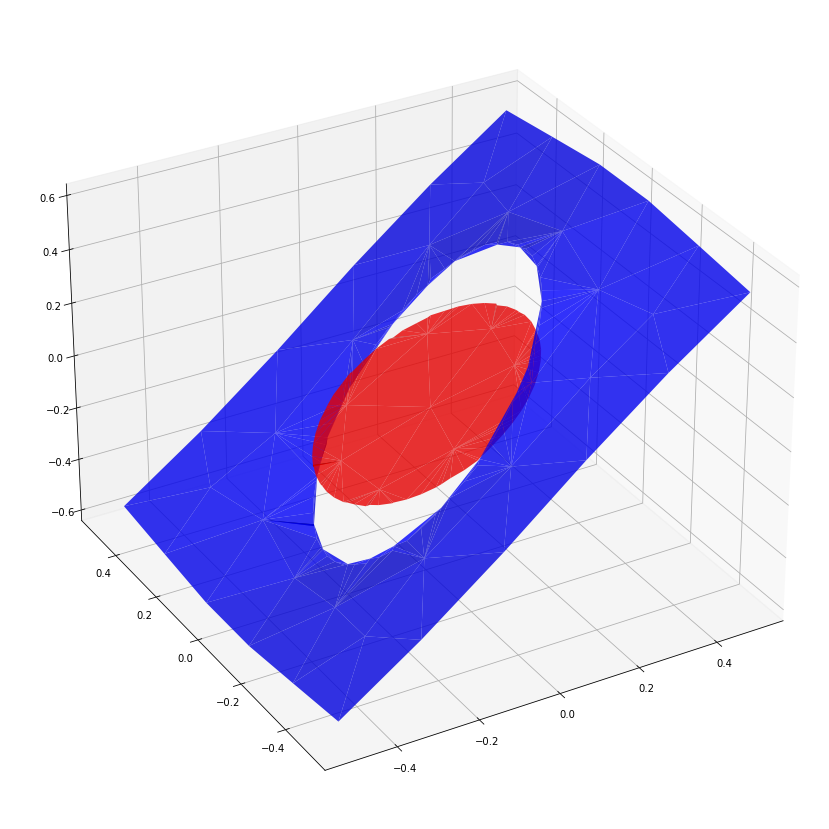

In [155]:
n = 9
u = sol_iterations[n]
plot_solution(mesh, u, elevation=30, azimuth=-120)

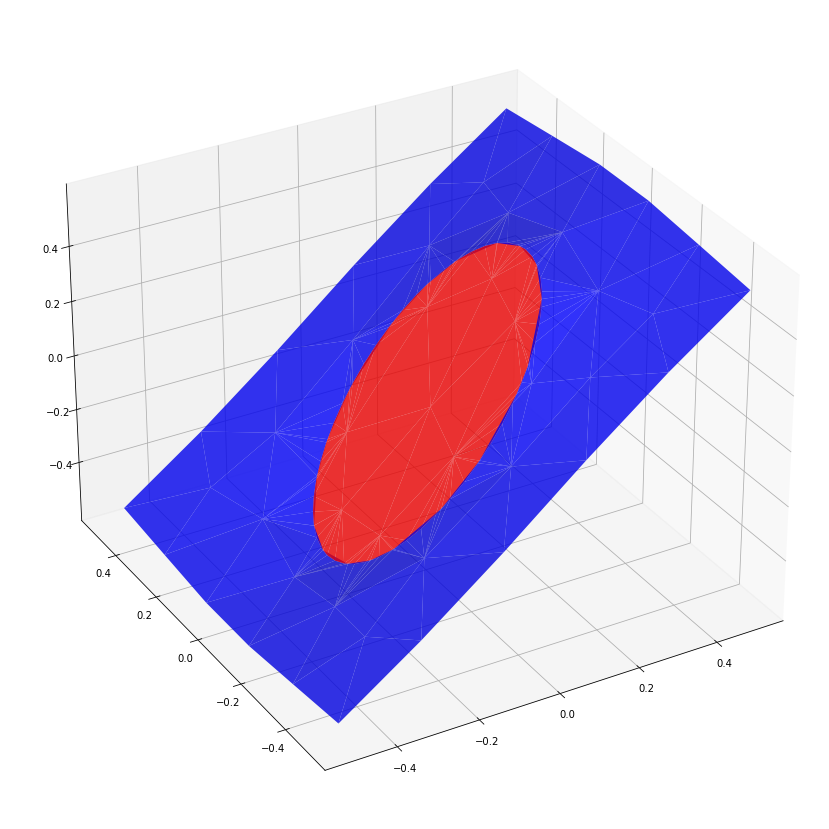

In [154]:
u_ref = [ ref_sol(mesh,dof,t=0) for dof in range(mesh.Ndof)]
plot_solution(mesh, u_ref, elevation=30, azimuth=-120)

In [121]:
def calc_energy_error (mesh, u, ref_sol, G_no_sigma, N_gamma, S, t):
    u_ref = np.array([ ref_sol(mesh,dof, t) for dof in range(mesh.Ndof)])
    err = u - u_ref
    contrib_1 = np.dot(np.dot(G_no_sigma,err),err)
    contrib_2 = np.dot(np.dot(N_gamma,err),err)
    contrib_3 = np.dot(np.dot(S,err),err)
    return np.sqrt(contrib_1+contrib_2+contrib_3)

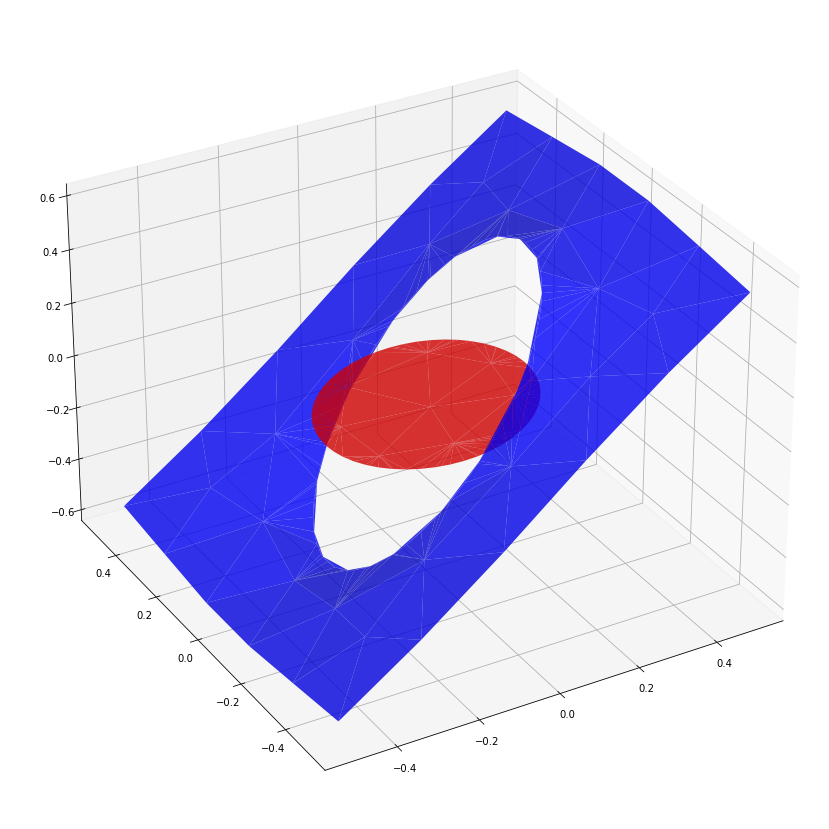

0.4302869839978514


In [158]:
### Compare Final Solution with Solution at Equilibrium
n = 10

u_ref = ref_iterations[n] 
plot_solution(mesh, u_ref, elevation=30, azimuth=-120)

u = sol_iterations[n]
err_energy = calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S, t) #-->adapted
print (err_energy)

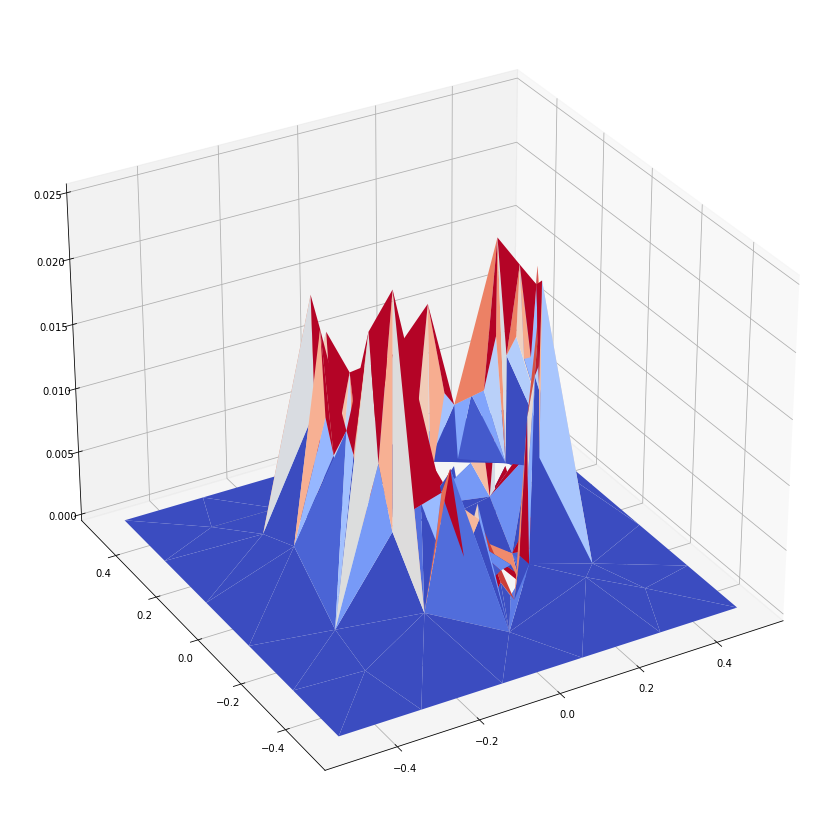

In [127]:
ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-120)

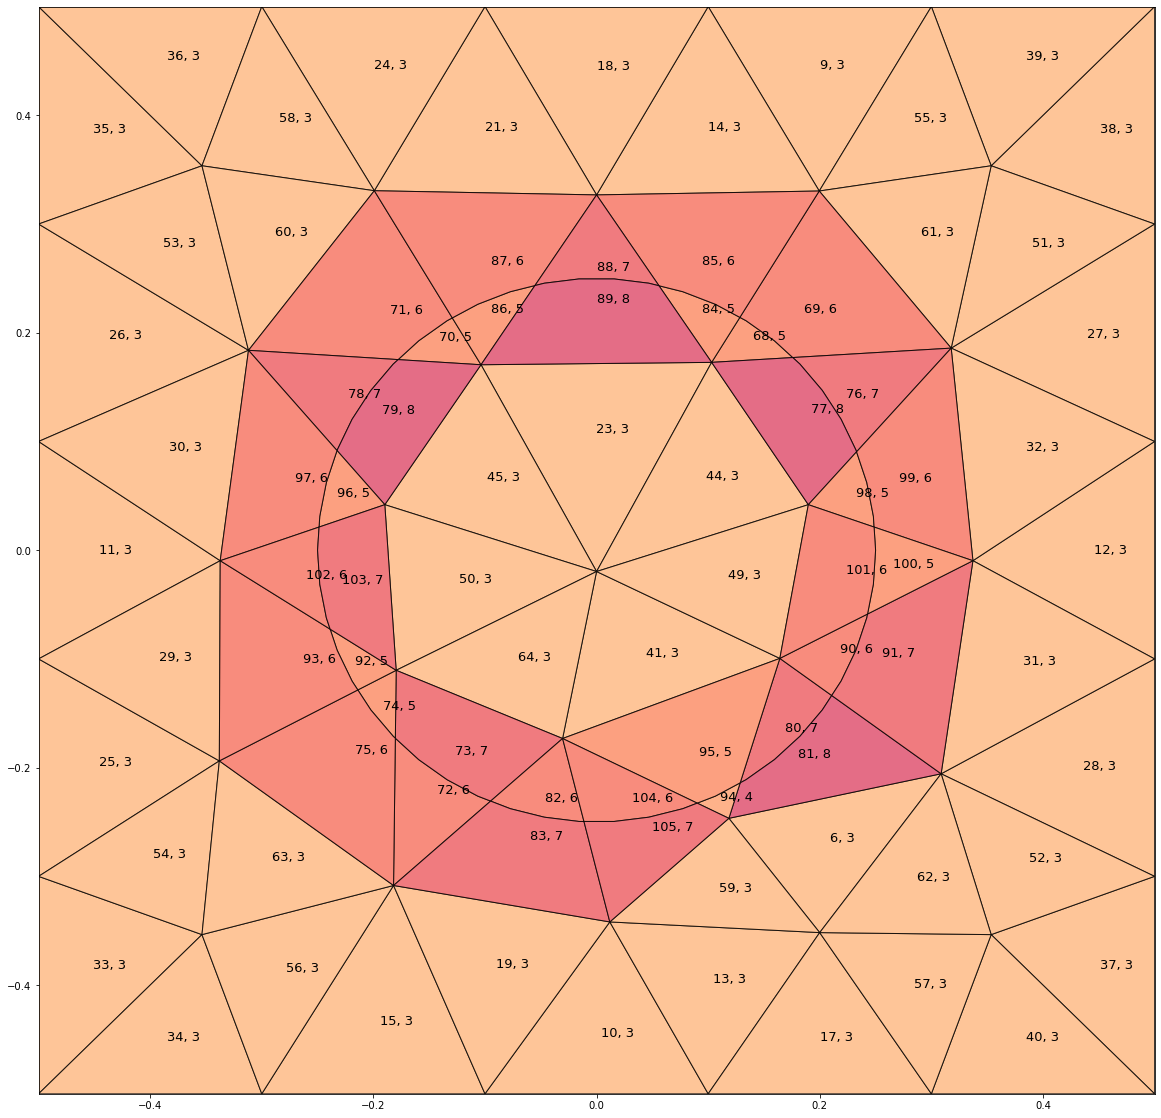

In [85]:
colmap = plt.get_cmap('magma')

# function to visualize
def visualize_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
 
    for ifa in range(mesh.Nfaces): 
        if (mesh.cut_faces[ifa]!=1):
            verts = []
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            
            # draw polygon
            for ino in range(node_per_face):
                point = mesh.coords[mesh.faces[ifa,ino],:]
                verts.append(point[0:2])
            element = Polygon(verts, closed=True, edgecolor='black',\
                              facecolor=colmap(1-node_per_face/20), alpha=0.8)
            ax.add_patch(element)
            
            # write no of vertices
            bary = ddr.barycenter(mesh, ifa)
            text_pos = bary
            text= str(ifa)+", "+str(node_per_face)
            ax.text(text_pos[0], text_pos[1], text, fontsize=13, color='black')
            

visualize_mesh(mesh)

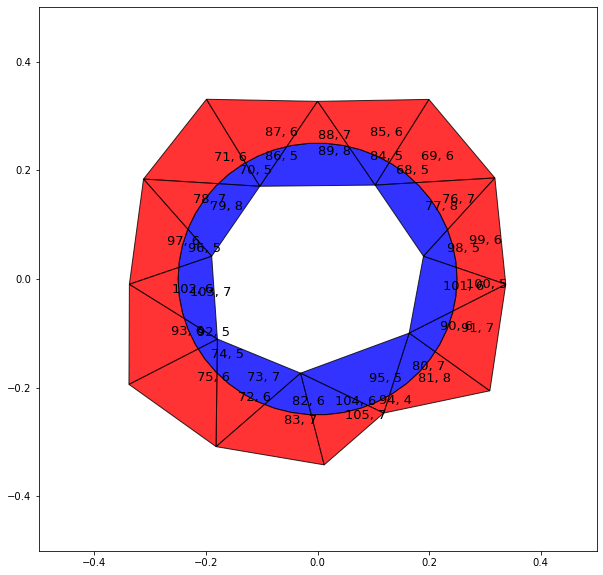

In [86]:
colors = ['blue', 'red']

# function to visualize
def check_intf_couples (mesh):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
 
    for couple in mesh.gamma_couples:
        for idx, face in enumerate(couple):
            verts = []
            node_per_face = np.count_nonzero(mesh.faces[face,:] != -1)
            
            # draw polygon
            for ino in range(node_per_face):
                point = mesh.coords[mesh.faces[face,ino],:]
                verts.append(point[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', \
                              facecolor=colors[idx], alpha=0.8)
            ax.add_patch(element)
            
            # write no of vertices
            bary = ddr.barycenter(mesh, face)
            text_pos = bary
            text= str(face)+", "+str(node_per_face)
            ax.text(text_pos[0], text_pos[1], text, fontsize=13, color='black')
            

check_intf_couples(mesh)

In [33]:
# test reconstruction: initialize poli1 function and check gradient and recpot 
# recpot should be exact for pol1

u = np.zeros(mesh.Npoints)
for ino in range(mesh.Npoints):
    x = mesh.coords[ino,0]
    y = mesh.coords[ino,0]
    u[ino] = x + y

for ifa in range(mesh.Nfaces):
    if (mesh.cut_faces[ifa]!=1):
        print ("Face no:", ifa)
        node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
        u_F = u[mesh.faces[ifa,0:node_per_face]]
        grad = ddr.GR(mesh, ifa)
        print("Nodal values", u_F)
        print ("Gradient: ", np.dot(grad,u_F))
        R = ddr.recpot(mesh, ifa)
        print("Reconstruction", np.dot(R,u_F))
        print ("*************")
        if (np.linalg.norm( u_F- np.dot(R,u_F) )>1e-6):
            
            print ("Error")

Face no: 1
Nodal values [0.82074078 0.83352647 0.63024155]
Gradient:  [2. 0.]
Reconstruction [0.82074078 0.83352647 0.63024155]
*************
Face no: 2
Nodal values [0.63024155 0.66519238 0.82074078]
Gradient:  [2. 0.]
Reconstruction [0.63024155 0.66519238 0.82074078]
*************
Face no: 3
Nodal values [0.62196288 0.82649409 0.82679492]
Gradient:  [2. 0.]
Reconstruction [0.62196288 0.82649409 0.82679492]
*************
Face no: 4
Nodal values [-0.81526415 -0.59842297 -0.70499209]
Gradient:  [2.0000000e+00 8.8817842e-16]
Reconstruction [-0.81526415 -0.59842297 -0.70499209]
*************
Face no: 5
Nodal values [-0.81886055 -0.70101521 -0.60118215]
Gradient:  [2. 0.]
Reconstruction [-0.81886055 -0.70101521 -0.60118215]
*************
Face no: 6
Nodal values [0.50707913 0.68138725 0.63359727]
Gradient:  [2. 0.]
Reconstruction [0.50707913 0.68138725 0.63359727]
*************
Face no: 7
Nodal values [0.62196288 0.67610624 0.82649409]
Gradient:  [2. 0.]
Reconstruction [0.62196288 0.6761062

Reconstruction [-2.00000000e-01 -9.99999997e-02  2.75239500e-12]
*************
Face no: 73
Nodal values [-1.         -0.81526415 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.81526415 -1.        ]
*************
Face no: 74
Nodal values [1.         0.82074078 1.        ]
Gradient:  [2. 0.]
Reconstruction [1.         0.82074078 1.        ]
*************
Face no: 75
Nodal values [-1.         -0.84740337 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.84740337 -1.        ]
*************
Face no: 76
Nodal values [-0.2 -0.3 -0.4]
Gradient:  [2.0000000e+00 4.4408921e-16]
Reconstruction [-0.2 -0.3 -0.4]
*************
Face no: 77
Nodal values [1.         0.82679492 1.        ]
Gradient:  [2. 0.]
Reconstruction [1.         0.82679492 1.        ]
*************
Face no: 78
Nodal values [-1.        -0.8222914 -1.       ]
Gradient:  [2. 0.]
Reconstruction [-1.        -0.8222914 -1.       ]
*************
Face no: 79
Nodal values [-0.4        -0.49180023 -0.6       ]
Gr

Reconstruction [0.63024155 0.40392492 0.49428908]
*************
Face no: 143
Nodal values [1.92785637e-06 2.00113422e-01 9.54767611e-02]
Gradient:  [2. 0.]
Reconstruction [1.92785637e-06 2.00113422e-01 9.54767611e-02]
*************
Face no: 145
Nodal values [0.3        0.49985875 0.4       ]
Gradient:  [2.0000000e+00 4.4408921e-16]
Reconstruction [0.3        0.49985875 0.4       ]
*************
Face no: 147
Nodal values [0.20000193 0.40392492 0.3       ]
Gradient:  [2. 0.]
Reconstruction [0.20000193 0.40392492 0.3       ]
*************
Face no: 148
Nodal values [0.49428908 0.29915821 0.41814196]
Gradient:  [2. 0.]
Reconstruction [0.49428908 0.29915821 0.41814196]
*************
Face no: 149
Nodal values [0.29915821 0.40392492 0.20000193]
Gradient:  [2. 0.]
Reconstruction [0.29915821 0.40392492 0.20000193]
*************
Face no: 150
Nodal values [0.49428908 0.40392492 0.29915821]
Gradient:  [2. 0.]
Reconstruction [0.49428908 0.40392492 0.29915821]
*************
Face no: 151
Nodal values 

Reconstruction [-0.3        -0.2        -0.09999999]
*************
Face no: 204
Nodal values [-0.5 -0.4 -0.3]
Gradient:  [2.0000000e+00 8.8817842e-16]
Reconstruction [-0.5 -0.4 -0.3]
*************
Face no: 205
Nodal values [-0.4 -0.2 -0.3]
Gradient:  [2. 0.]
Reconstruction [-0.4 -0.2 -0.3]
*************
Face no: 206
Nodal values [1.00000005e-01 3.14870324e-10 2.00000000e-01]
Gradient:  [2.00000000e+00 1.11599821e-17]
Reconstruction [1.00000005e-01 3.14870431e-10 2.00000000e-01]
*************
Face no: 207
Nodal values [0.2 0.4 0.3]
Gradient:  [2. 0.]
Reconstruction [0.2 0.4 0.3]
*************
Face no: 208
Nodal values [-2.00000000e-01  3.14870324e-10 -9.99999938e-02]
Gradient:  [2.00000000e+00 7.08814764e-17]
Reconstruction [-2.00000000e-01  3.14870495e-10 -9.99999938e-02]
*************
Face no: 209
Nodal values [-9.99999938e-02  3.14870324e-10  1.00000005e-01]
Gradient:  [ 2.00000000e+00 -1.55587065e-17]
Reconstruction [-9.99999938e-02  3.14870332e-10  1.00000005e-01]
*************
Fac

Reconstruction [-0.31794217 -0.31871199 -0.34227355 -0.36448431 -0.36810206 -0.39463417]
*************
Face no: 265
Nodal values [-0.36810206 -0.36448431 -0.34227355 -0.31871199 -0.31794217 -0.19962922
 -0.29792602]
Gradient:  [ 2.00000000e+00 -2.22044605e-16]
Reconstruction [-0.36810206 -0.36448431 -0.34227355 -0.31871199 -0.31794217 -0.19962922
 -0.29792602]
*************
Face no: 266
Nodal values [-0.2325717  -0.21288965 -0.18406228 -0.1545085  -0.14655463 -0.19962922]
Gradient:  [2.0000000e+00 8.8817842e-16]
Reconstruction [-0.2325717  -0.21288965 -0.18406228 -0.1545085  -0.14655463 -0.19962922]
*************
Face no: 267
Nodal values [-0.14655463 -0.1545085  -0.18406228 -0.21288965 -0.2325717  -0.3
 -0.09999999]
Gradient:  [2. 0.]
Reconstruction [-0.14655463 -0.1545085  -0.18406228 -0.21288965 -0.2325717  -0.3
 -0.09999999]
*************
Face no: 268
Nodal values [-0.31794217 -0.29389263 -0.2679134  -0.24087684 -0.2325717  -0.19962922]
Gradient:  [2. 0.]
Reconstruction [-0.3179421

Reconstruction [0.11084578 0.12434494 0.1545085  0.17746459 0.29915821 0.20000193]
*************
Face no: 304
Nodal values [-0.40385212 -0.38664725 -0.41939966]
Gradient:  [2.00000000e+00 1.77635684e-15]
Reconstruction [-0.40385212 -0.38664725 -0.41939966]
*************
Face no: 305
Nodal values [-0.38664725 -0.40385212 -0.29878959 -0.19968865]
Gradient:  [2. 0.]
Reconstruction [-0.38664725 -0.40385212 -0.29878959 -0.19968865]
*************
Face no: 306
Nodal values [-0.45110936 -0.43815334 -0.42216396 -0.4045085  -0.38525662 -0.36810206
 -0.29792602]
Gradient:  [ 2.00000000e+00 -1.33226763e-15]
Reconstruction [-0.45110936 -0.43815334 -0.42216396 -0.4045085  -0.38525662 -0.36810206
 -0.29792602]
*************
Face no: 307
Nodal values [-0.36810206 -0.38525662 -0.4045085  -0.42216396 -0.43815334 -0.45110936
 -0.49037914 -0.39463417]
Gradient:  [2. 0.]
Reconstruction [-0.36810206 -0.38525662 -0.4045085  -0.42216396 -0.43815334 -0.45110936
 -0.49037914 -0.39463417]
*************
Face no: 

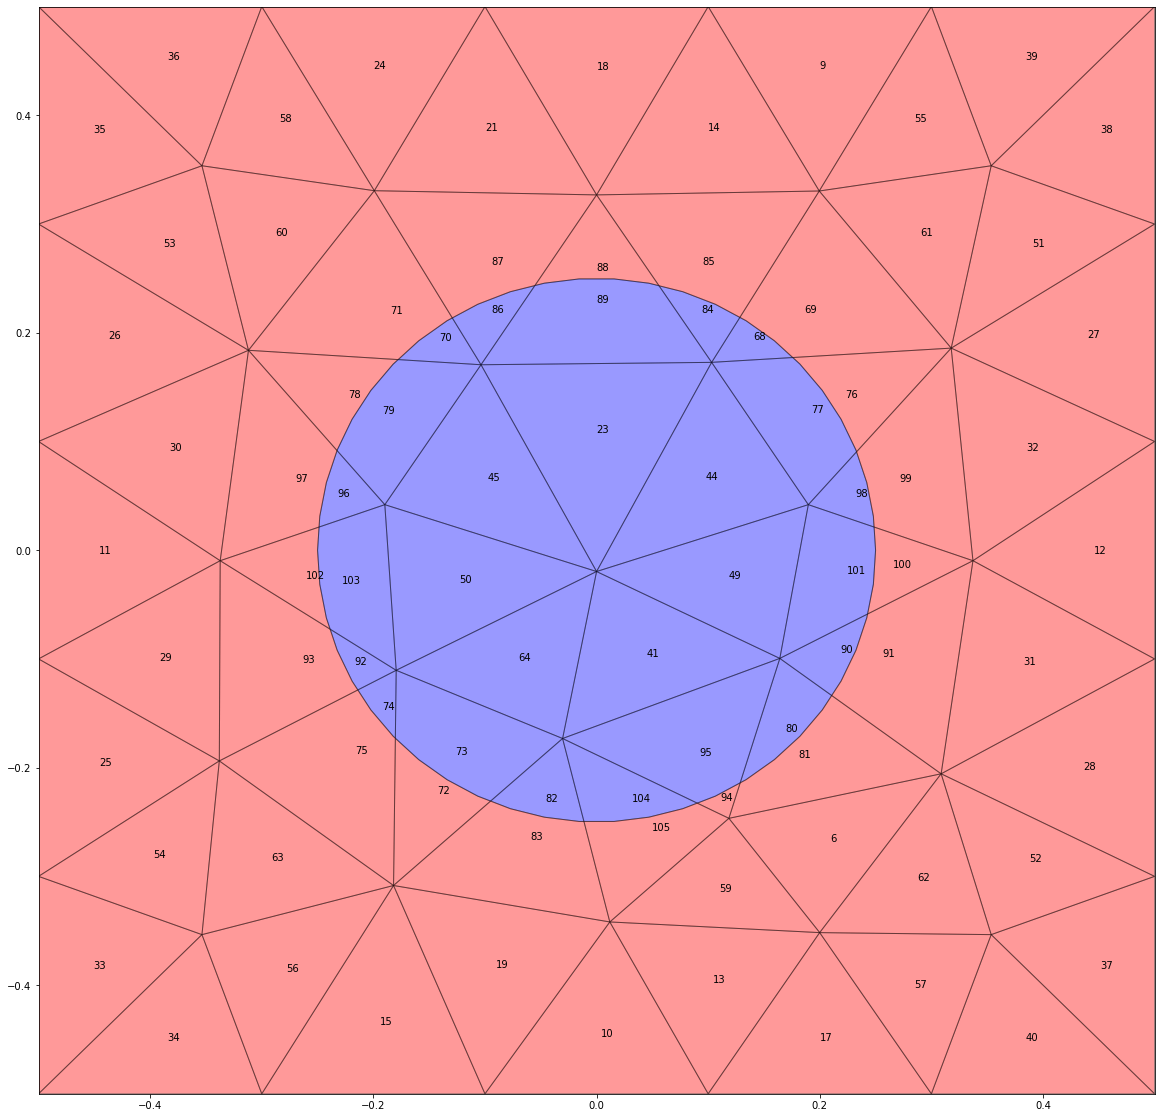

In [87]:
# function to visualize
def check_normals(mesh, display_normal = False):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
    colors = ['blue', 'red']
 
    for ifa in range(mesh.faces.shape[0]): 
        if (mesh.cut_faces[ifa]!=1):
            verts = []
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            
            # draw polygon and display normal
            for ino in range(node_per_face):
                point = mesh.coords[mesh.faces[ifa,ino],:]
                verts.append(point[0:2])
                if (display_normal):
                    if (ino<mesh.no_intf_edges[ifa]):
                        p1 = mesh.coords[mesh.faces[ifa,ino]]
                        p2 = mesh.coords[mesh.faces[ifa,ino+1]]
                        start = 0.5*(p1+p2)
                        tang = (p2-p1)[0:2]/np.linalg.norm((p2-p1)[0:2])/50

                        if (np.linalg.norm(p2-p1)<1e-16):
                             print ("Problem at Face: ", ifa)
                             print ("Nodes: ", ino, ino+1)
                        
                        dx = np.dot( np.array([[0, 1], [-1, 0]]), tang)
                        sign = 2*( (1-mesh.side_mask[ifa]) -0.5)
                        dx = dx*sign
                        ax.arrow(start[0], start[1], dx[0], dx[1])
                
            element = Polygon(verts, closed=True, edgecolor='black',\
                              facecolor=colors[int(mesh.side_mask[ifa])], alpha=0.4)
            ax.add_patch(element)
            
            # write no of element
            text_pos = ddr.barycenter(mesh, ifa)
            text = str(ifa) 
            ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='black')
            
            

check_normals(mesh)